In [1]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/work2/Final/Text_Work/Files/updated_transcriptions_with_senti (1).csv')

df.head()


,Sentence,Label
0,السلام علیکم میرا نام حریم ہے اور اج میں اپ کو...,2
1,السلام علیکم میرا نام حریم ہے اور اج میں اپ کو...,1
2,السلام علیکم ناظرین اج میں اپ کو بتاؤں گی میز ...,0
3,کافی حد تک گیم ہے میں نے بہت بڑا ہے جب بھی خیر...,1
4,بہت اچھے لگے میں تو بہت لائک کرتا ہوں کھاتا ہو...,1


In [ ]:
!pip install urduhack


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.5/105.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.8/82.8 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 21.0 MB/s eta 0:00:00
  Attempting uninstall: Click
    Found existing installation: click 8.1.7
    Uninstalling click-8.1.7:
      Successfully uninstalled click-8.1.7
  Attempting uninstall: tensorflow-datasets
    Found existing installation: tensorflow-datasets 4.9.4
    Uninstalling tensorflow-datasets-4.9.4:
      Successfully uninstalled tensorflow-datasets-4.9.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flask 2.2.5 requires click>=8.0, but you have click 7.1.2 which is

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
<ipython-input-8-36777a5abda5>:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['F1 Score'], y=[f1], palette="viridis")
<ipython-input-8-36777a5abda5>:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Pr

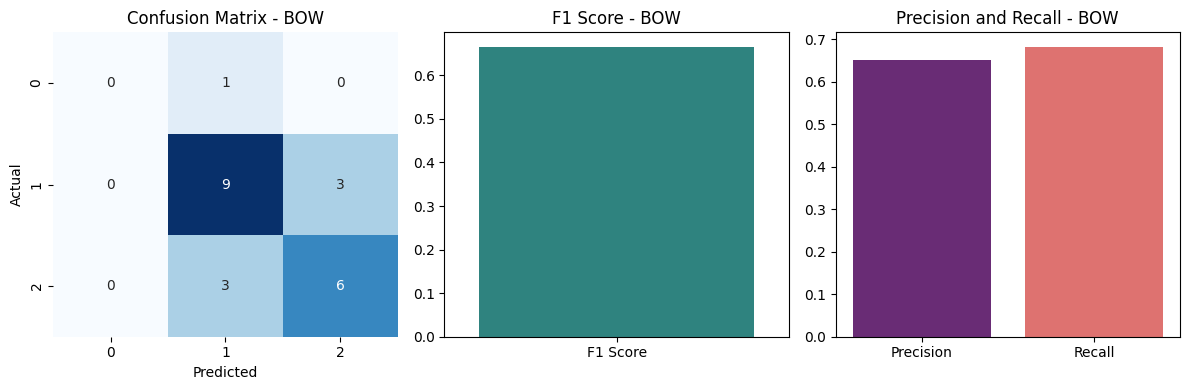

Testing Score with BOW features: 0.6818181818181818


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
<ipython-input-8-36777a5abda5>:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['F1 Score'], y=[f1], palette="viridis")
<ipython-input-8-36777a5abda5>:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Precision', 'Recall'], y=[precision, recall], palette="magma")


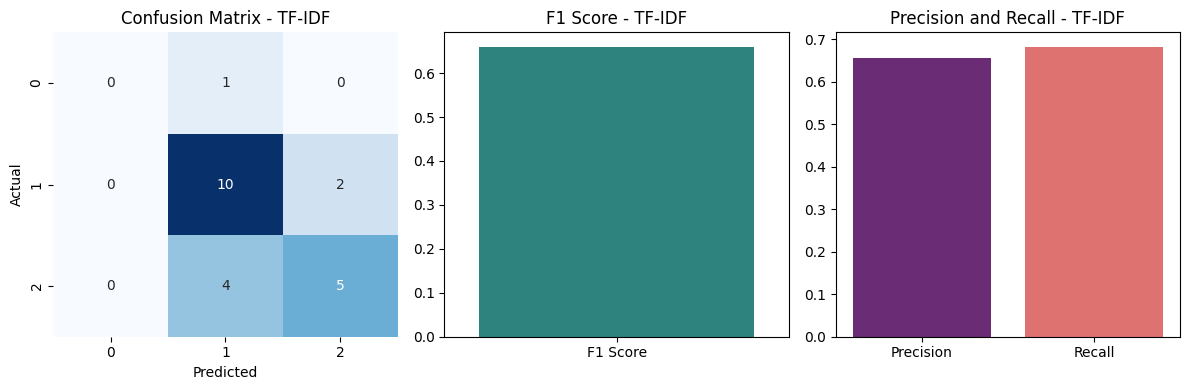

Testing Score with TF-IDF features: 0.6818181818181818


In [ ]:
import pandas as pd
import re
import nltk
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/work2/Final/Text_Work/Files/updated_transcriptions_with_senti (1).csv", encoding='utf-8')

# Remove unwanted characters, stopwords, and format the text
def removing_unwanted_data(text):
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', '', text)
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'\'', ' ', text)
    text = nltk.WordPunctTokenizer().tokenize(text)
    return text

df['text_cleaned'] = df['Sentence'].apply(removing_unwanted_data)

# Convert text to BOW and TF-IDF features
BOW_convert = CountVectorizer(tokenizer=lambda doc: doc, lowercase=False)
X_bow = BOW_convert.fit_transform(df['text_cleaned'])
tfidf_transformer = TfidfTransformer(norm=None)
X_tfidf = tfidf_transformer.fit_transform(X_bow)

# @@@
# Split the dataset into training and testing sets
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, df['Label'], test_size=0.2, random_state=42)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, df['Label'], test_size=0.2, random_state=42)

# Function to train and evaluate Logistic Regression
def logistic_regression(X_tr, y_tr, X_te, y_te, description, class_labels=None):
    model = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Calculate metrics
    cm = confusion_matrix(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='weighted')
    precision = precision_score(y_te, y_pred, average='weighted')
    recall = recall_score(y_te, y_pred, average='weighted')

    # Display confusion matrix
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    if class_labels is not None:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=class_labels, yticklabels=class_labels)
    else:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix - {}".format(description))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # Plot F1 Score
    plt.subplot(1, 3, 2)
    sns.barplot(x=['F1 Score'], y=[f1], palette="viridis")
    plt.title("F1 Score - {}".format(description))

    # Plot Precision and Recall
    plt.subplot(1, 3, 3)
    sns.barplot(x=['Precision', 'Recall'], y=[precision, recall], palette="magma")
    plt.title("Precision and Recall - {}".format(description))

    plt.tight_layout()
    plt.show()

    print('Testing Score with', description, 'features:', model.score(X_te, y_te))
    return model.score(X_te, y_te)

# Train and evaluate Logistic Regression with BOW and TF-IDF features
accuracy_bow = logistic_regression(X_train_bow, y_train, X_test_bow, y_test, "BOW")
accuracy_tfidf = logistic_regression(X_train_tfidf, y_train, X_test_tfidf, y_test, "TF-IDF")
